## 1. 导入实验所需库

- OpenCV：图像处理
- NumPy：矩阵运算
- PIL：图像读写
- Matplotlib：可视化

In [3]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

## 2. 图像读取

OpenCV 默认读取为 BGR 格式，而 matplotlib 采用 RGB 格式，
因此显示前需要进行颜色空间转换。

In [12]:
img_bgr = cv2.imread("sample.png")

if img_bgr is None:
    raise FileNotFoundError("未找到 sample.png")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

## 3. 图像基本属性

图像本质上是一个三维矩阵：

(H, W, C)

其中：

- H：高度
- W：宽度
- C：通道数

In [17]:
print("图像形状：", img_rgb.shape)
print("数据类型：", img_rgb.dtype)
print("最大像素值：", img_rgb.max())
print("最小像素值：", img_rgb.min())

图像形状： (1236, 1450, 3)
数据类型： uint8
最大像素值： 255
最小像素值： 0


## 4. 图像可视化

分别显示：

1. 原始 RGB 图像
2. 红色通道
3. 灰度图像

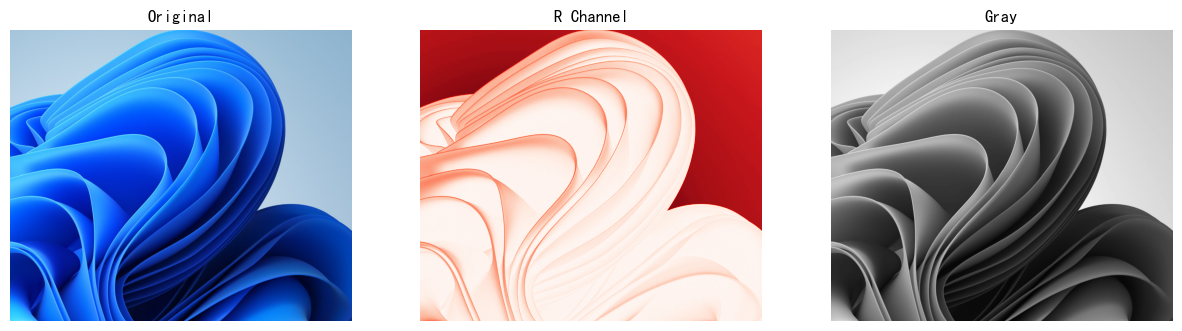

In [20]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1,3,figsize=(15,5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")

axes[1].imshow(img_rgb[:,:,0], cmap="Reds")
axes[1].set_title("R Channel")

axes[2].imshow(gray, cmap="gray")
axes[2].set_title("Gray")

for ax in axes:
    ax.axis("off")

plt.show()

## 5. 图像缩放

深度学习模型通常要求固定输入尺寸：

- ResNet：224×224
- ViT：224×224
- CLIP：224×224

In [23]:
resized = cv2.resize(img_bgr, (224,224))

resized_keep = cv2.resize(
    img_bgr,
    (
        int(img_bgr.shape[1]*0.5),
        int(img_bgr.shape[0]*0.5)
    )
)

print(resized.shape)
print(resized_keep.shape)

(224, 224, 3)
(618, 725, 3)


## 6. 数据归一化

神经网络训练通常需要：

### Step1

像素：

0~255

↓

0~1

### Step2

进行 ImageNet 标准化：

\[
x'=\frac{x-\mu}{\sigma}
\]

In [26]:
img_float = img_rgb.astype(np.float32) / 255.0

mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

img_normalized = (img_float - mean) / std

print(img_normalized.mean())
print(img_normalized.std())

0.07298832620905364
1.6323779499888225


## 7. 颜色空间转换

常见颜色空间：

- RGB：显示使用
- Gray：边缘检测
- HSV：颜色分析、目标跟踪

In [29]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

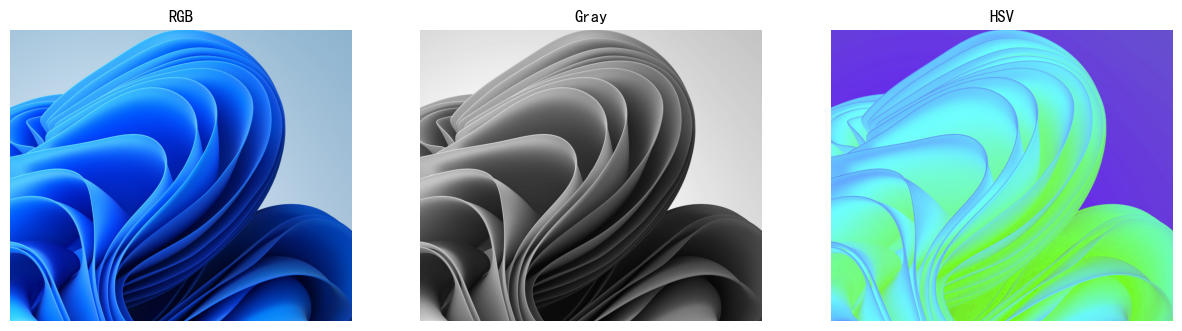

In [31]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

axes[0].imshow(img_rgb)
axes[0].set_title("RGB")

axes[1].imshow(gray,cmap='gray')
axes[1].set_title("Gray")

axes[2].imshow(hsv)
axes[2].set_title("HSV")

for ax in axes:
    ax.axis("off")

plt.show()

## 8. 图像平滑

高斯模糊能够降低噪声，对于后续边缘检测十分重要。

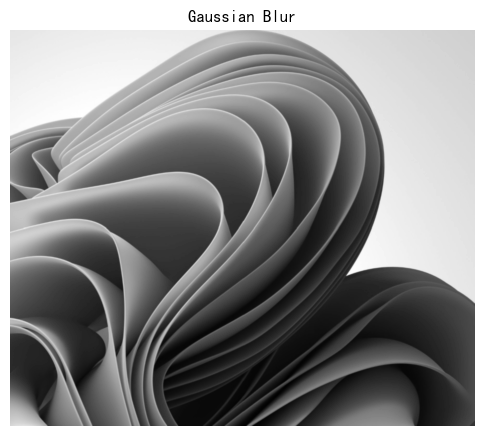

In [34]:
blurred = cv2.GaussianBlur(gray, (5,5), 0)

plt.figure(figsize=(6,6))
plt.imshow(blurred, cmap='gray')
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

## 9. Canny 边缘检测

Canny 是经典边缘检测算法：

1. 去噪
2. 计算梯度
3. 非极大值抑制
4. 双阈值筛选

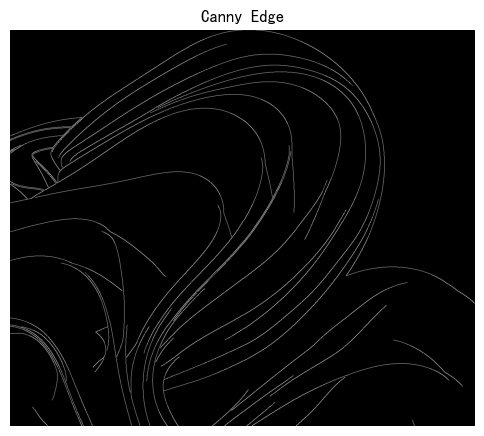

In [37]:
edges_canny = cv2.Canny(
    blurred,
    threshold1=50,
    threshold2=150
)

plt.figure(figsize=(6,6))
plt.imshow(edges_canny, cmap='gray')
plt.title("Canny Edge")
plt.axis("off")
plt.show()

## 10. Sobel 梯度特征

卷积核：

### x方向

\[
[-1,0,1]
\]

### y方向

\[
[-1,-2,-1]
\]

梯度反映图像纹理与边缘信息。

In [40]:
sobelx = cv2.Sobel(
    gray,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

sobely = cv2.Sobel(
    gray,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

gradient_mag = np.sqrt(
    sobelx**2 + sobely**2
)

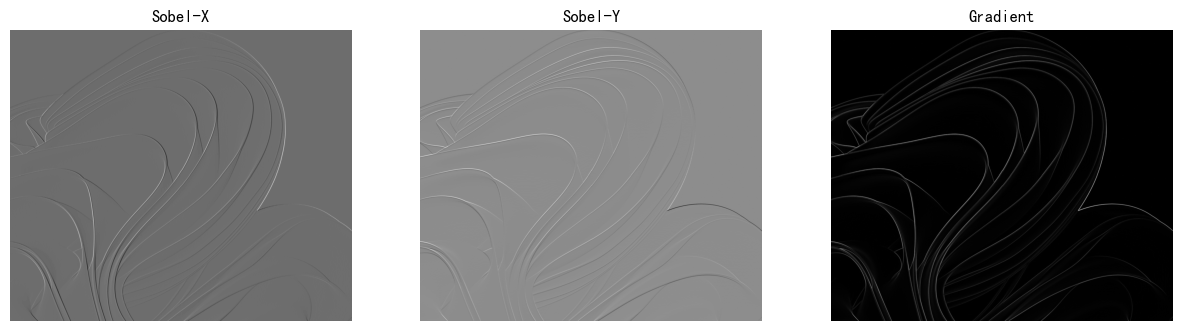

In [42]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

axes[0].imshow(sobelx,cmap='gray')
axes[0].set_title("Sobel-X")

axes[1].imshow(sobely,cmap='gray')
axes[1].set_title("Sobel-Y")

axes[2].imshow(gradient_mag,cmap='gray')
axes[2].set_title("Gradient")

for ax in axes:
    ax.axis("off")

plt.show()

## 11. 图像直方图分析

颜色直方图描述：

每种像素值出现的频率。

在图像检索、目标识别中具有重要作用。

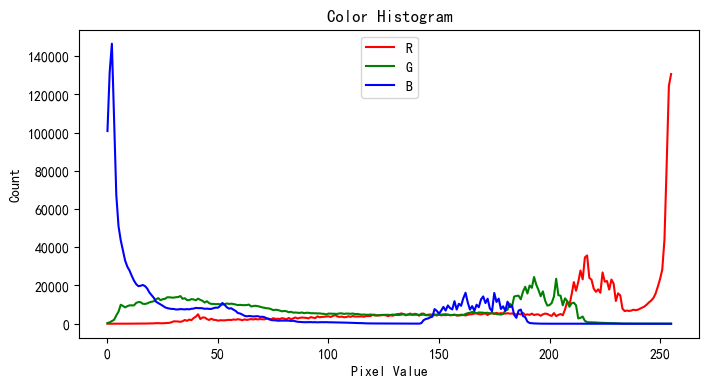

In [47]:
fig, ax = plt.subplots(figsize=(8,4))

colors = ('r','g','b')

for i, color in enumerate(colors):

    hist = cv2.calcHist(
        [img_bgr],
        [i],
        None,
        [256],
        [0,256]
    )

    ax.plot(
        hist.flatten(),
        color=color,
        label=color.upper()
    )

ax.set_xlabel("Pixel Value")
ax.set_ylabel("Count")
ax.set_title("Color Histogram")
ax.legend()

plt.savefig(
    "histogram.pdf",
    bbox_inches='tight'
)

plt.show()